# Script 09 — Rating Prediction
## Can a model learn my taste and predict what rating I'd give a film?

This notebook trains a **Random Forest Regressor** on my 757 rated films.

**Pipeline:**
1. Build feature matrix (same as script 06)
2. Split into train (80%) and test (20%)
3. Train Random Forest
4. Evaluate: MAE, RMSE, R²
5. Compare against a naive baseline
6. Feature importance — what actually drives my ratings?
7. Predict ratings for watchlist and discovery candidates


## 1. Imports and setup

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Paths
ROOT_DIR  = os.path.join(os.getcwd(), '..')
DATA_DIR  = os.path.join(ROOT_DIR, 'data', 'processed')
RAW_DIR   = os.path.join(ROOT_DIR, 'data', 'raw')
OUT_DIR   = os.path.join(ROOT_DIR, 'output')
os.makedirs(OUT_DIR, exist_ok=True)

# Plot style
plt.rcParams.update({
    'figure.facecolor':  '#0a0a0f',
    'axes.facecolor':    '#111118',
    'axes.edgecolor':    '#333344',
    'axes.labelcolor':   '#9999b8',
    'axes.titlecolor':   '#e8e8f0',
    'axes.titlesize':    12,
    'axes.titlepad':     12,
    'axes.grid':         True,
    'grid.color':        '#1e1e2e',
    'grid.linewidth':    0.6,
    'xtick.color':       '#666680',
    'ytick.color':       '#666680',
    'text.color':        '#e8e8f0',
    'font.family':       'monospace',
})
GOLD = '#e8c96a'; GREEN = '#00c030'; RED = '#e84040'; TEAL = '#00ccaa'; PURPLE = '#9966ff'

## 2. Load and explore the data

In [25]:
df = pd.read_csv(os.path.join(DATA_DIR, 'movies_enriched.csv'))
df = df[df['Rating'].notna() & df['genres'].notna()].copy().reset_index(drop=True)

print(f"Films available for training: {len(df)}")
print(f"Rating distribution:")
print(df['Rating'].value_counts().sort_index())
print(f"\nMean rating: {df['Rating'].mean():.2f}")
print(f"Std dev:     {df['Rating'].std():.2f}")


Films available for training: 757
Rating distribution:
Rating
0.5     30
1.0     42
1.5     46
2.0     52
2.5     49
3.0     90
3.5    109
4.0    138
4.5     96
5.0    105
Name: count, dtype: int64

Mean rating: 3.32
Std dev:     1.28


## 3a. Fetch production companies from TMDb

Production company is one of the strongest signals for your taste.
A24, Neon, MUBI films get very different ratings than Marvel or DC.
This cell fetches companies for all films and caches results.


In [26]:
import json
import requests, time

env_path = os.path.join(ROOT_DIR, '.env')
API_KEY = None
if os.path.exists(env_path):
    with open(env_path, 'r') as f:
        for line in f:
            if line.startswith('TMDB_KEY='):
                API_KEY = line.split('=', 1)[1].strip()

CACHE_FILE = os.path.join(DATA_DIR, 'companies_cache.json')
companies_cache = {}
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE, 'r', encoding='utf-8') as f:
        companies_cache = json.load(f)
    print(f"Cache loaded: {len(companies_cache)} films")

def fetch_companies(tmdb_id):
    if not tmdb_id or str(tmdb_id) == 'nan':
        return ''
    key = str(int(float(tmdb_id)))
    if key in companies_cache:
        return companies_cache[key]
    try:
        r = requests.get(
            f'https://api.themoviedb.org/3/movie/{key}',
            params={'api_key': API_KEY}, timeout=10
        )
        r.raise_for_status()
        data = r.json()
        companies = '|'.join(c['name'] for c in data.get('production_companies', []))
        companies_cache[key] = companies
        time.sleep(0.15)
        return companies
    except:
        return ''

# Only fetch if column doesn't exist yet
if 'production_companies' not in df.columns:
    print(f"Fetching production companies for {len(df)} films...")
    df['production_companies'] = [
        fetch_companies(row.get('tmdb_id'))
        for _, row in df.iterrows()
    ]
    with open(CACHE_FILE, 'w', encoding='utf-8') as f:
        json.dump(companies_cache, f, ensure_ascii=False)
    df.to_csv(os.path.join(DATA_DIR, 'movies_enriched.csv'), index=False, encoding='utf-8')
    print("Done! Saved to movies_enriched.csv")
else:
    print("Production companies already in dataset — skipping fetch.")

# Show top companies with avg rating
comp_exp = df[df['production_companies'].notna()].assign(
    company=df['production_companies'].str.split('|')
).explode('company')
comp_exp = comp_exp[comp_exp['company'].str.strip() != '']
comp_stats = comp_exp.groupby('company').agg(
    films=('Name','count'), avg_rating=('Rating','mean')
).query('films >= 3').sort_values('avg_rating', ascending=False)

print(f"\nYour top production companies by avg rating (min 3 films):")
print(comp_stats.head(15).to_string())


Cache loaded: 756 films
Production companies already in dataset — skipping fetch.

Your top production companies by avg rating (min 3 films):
                                       films  avg_rating
company                                                 
Attic Bedroom                              4    5.000000
Pulse Films                                3    5.000000
Lord Miller                                3    4.833333
RT Features                                5    4.600000
Studio Ghibli                              5    4.600000
Parts & Labor                              3    4.500000
Nippon Television Network Corporation      3    4.500000
Mitsubishi                                 3    4.500000
JW Films                                   4    4.500000
Sony Pictures Animation                    3    4.500000
Searchlight Pictures                       3    4.500000
Wild Bunch                                 3    4.500000
Tokuma Shoten                              4    4.500000
3 A

## 3b. Build enriched feature matrix

**Old approach:** binary flags (0/1) for genres and directors.

**New approach:** weighted features based on your actual rating history.
- Director → your avg rating for that director's films
- Genre → your avg rating for that genre
- Country → your avg rating for that country
- Decade → your avg rating for that decade
- Production company → your avg rating for that company (binary, top 20)
- Franchise → avg rating of previous films in same series you've seen
- TMDb bias → how much you diverge from crowd for this genre


In [27]:
import json

# Pre-compute weighted averages from my history

# Director avg rating
dir_exp = df[df['directors'].notna()].assign(
    director=df['directors'].str.split('|')
).explode('director')
dir_avg_rating = dir_exp.groupby('director')['Rating'].mean().to_dict()

# Genre avg rating  
genre_exp = df[df['genres'].notna()].assign(
    genre=df['genres'].str.split('|')
).explode('genre')
genre_avg_rating = genre_exp.groupby('genre')['Rating'].mean().to_dict()

# Country avg rating
country_exp = df[df['countries'].notna()].assign(
    country=df['countries'].str.split('|')
).explode('country')
country_avg_rating = country_exp.groupby('country')['Rating'].mean().to_dict()

# Decade avg rating
df['decade'] = (df['Year'] // 10 * 10).astype(int)
decade_avg_rating = df.groupby('decade')['Rating'].mean().to_dict()

# TMDb bias per genre (your avg - tmdb avg, scaled)
df['tmdb_scaled'] = df['tmdb_rating'] / 2  # convert 0-10 to 0-5
genre_exp2 = df[df['genres'].notna()].assign(
    genre=df['genres'].str.split('|')
).explode('genre')
genre_bias = (genre_exp2.groupby('genre')['Rating'].mean() - 
              genre_exp2.groupby('genre')['tmdb_scaled'].mean()).to_dict()

# Production company avg rating
top_companies = comp_stats.head(20).index.tolist()

# Franchise detection — films sharing first significant word of title
# e.g. "Dune", "Spider-Man", "The Batman"
def get_franchise_key(name):
    words = str(name).split()
    # Skip articles
    skip = {'the','a','an'}
    for w in words:
        if w.lower() not in skip and len(w) > 2:
            return w.lower()
    return words[0].lower() if words else ''

df['franchise_key'] = df['Name'].apply(get_franchise_key)
franchise_avg = df.groupby('franchise_key')['Rating'].mean().to_dict()
franchise_count = df.groupby('franchise_key').size().to_dict()

# ── Feature builder ─-
global_avg = df['Rating'].mean()
year_min   = df['Year'].min()
year_max   = df['Year'].max()

top_genres_list    = genre_exp.groupby('genre').size().nlargest(20).index.tolist()
top_countries_list = country_exp.groupby('country').size().nlargest(10).index.tolist()
top_dirs_list      = dir_exp.groupby('director').size().nlargest(30).index.tolist()

def build_features_v2(row):
    vec = []

    # ── Basic numeric ──
    year_raw = row.get('Year', 2000)
    year = int(year_raw) if year_raw and str(year_raw) != 'nan' else 2000
    vec.append((year - year_min) / max(year_max - year_min, 1))
    
    decade = (year // 10) * 10
    vec.append((decade - 1920) / 100)
    
    runtime = float(row.get('runtime', 100) or 100)
    vec.append(runtime / 240)
    
    tmdb = float(row.get('tmdb_rating', 0) or 0)
    vec.append(tmdb / 10.0)

    # ── Weighted: decade avg rating ──
    vec.append(decade_avg_rating.get(decade, global_avg) / 5.0)

    # ── Weighted: genre avg ratings ──
    genres = str(row.get('genres', ''))
    film_genres = [g for g in genres.split('|') if g]
    
    for g in top_genres_list:
        vec.append(genre_avg_rating.get(g, global_avg) / 5.0 if g in genres else 0.0)
    
    if film_genres:
        bias = np.mean([genre_bias.get(g, 0) for g in film_genres])
    else:
        bias = 0.0
    vec.append(np.clip(bias / 2.0 + 0.5, 0, 1))

    # ── Weighted: country avg ratings ──
    countries = str(row.get('countries', ''))
    for c in top_countries_list:
        vec.append(country_avg_rating.get(c, global_avg) / 5.0 if c in countries else 0.0)

    # ── Weighted: director avg ratings ──
    directors = str(row.get('directors', ''))
    film_dirs = [d for d in directors.split('|') if d]
    
    for d in top_dirs_list:
        if d in directors:
            vec.append(dir_avg_rating.get(d, global_avg) / 5.0)
        else:
            vec.append(0.0)
    
    if film_dirs:
        dir_score = np.mean([dir_avg_rating.get(d, global_avg) for d in film_dirs])
    else:
        dir_score = global_avg
    vec.append(dir_score / 5.0)

    # ── Production company binary flags ──
    companies = str(row.get('production_companies', ''))
    for company in top_companies:
        vec.append(1.0 if company in companies else 0.0)

    # ── Franchise signal ──
    fkey = get_franchise_key(str(row.get('Name', '')))
    fcount = franchise_count.get(fkey, 0)
    if fcount >= 2:
        vec.append(franchise_avg.get(fkey, global_avg) / 5.0)
        vec.append(min(fcount / 5.0, 1.0))
    else:
        vec.append(global_avg / 5.0)
        vec.append(0.0)

    return vec

# Feature names for interpretability
feature_names_v2 = (
    ['year_norm', 'decade_norm', 'runtime_norm', 'tmdb_norm', 'decade_avg_rating'] +
    [f'genre_avg_{g.lower().replace(" ","_")}' for g in top_genres_list] +
    ['genre_tmdb_bias'] +
    [f'country_avg_{c.lower()}' for c in top_countries_list] +
    [f'dir_avg_{d.lower().replace(" ","_")[:18]}' for d in top_dirs_list] +
    ['director_quality_score'] +
    [f'company_{c.lower().replace(" ","_")[:18]}' for c in top_companies] +
    ['franchise_avg_rating', 'franchise_count']
)

print("Building enriched feature matrix...")
X_v2 = np.array([build_features_v2(row) for _, row in df.iterrows()], dtype=float)
X_v2 = np.nan_to_num(X_v2, nan=0.0)
y    = df['Rating'].values

print(f"Feature matrix: {X_v2.shape}")
print(f"Features: {len(feature_names_v2)}")
print(f"  - Basic numeric:       5")
print(f"  - Genre weighted:      {len(top_genres_list) + 1}")
print(f"  - Country weighted:    {len(top_countries_list)}")
print(f"  - Director weighted:   {len(top_dirs_list) + 1}")
print(f"  - Production company:  {len(top_companies)}")
print(f"  - Franchise:           2")

# Alias for compatibility with remaining cells
X = X_v2
feature_names = feature_names_v2


Building enriched feature matrix...
Feature matrix: (757, 88)
Features: 88
  - Basic numeric:       5
  - Genre weighted:      20
  - Country weighted:    10
  - Director weighted:   31
  - Production company:  20
  - Franchise:           2


## 4. Train / Test split

We keep 20% of films hidden from the model during training.
These are used to evaluate how well the model generalises.

**Why not train on everything?**
If we trained on all 757 films and then evaluated on the same films,
the model would just memorise them — we'd get 100% accuracy but
it would be useless for new films.


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_v2, y, test_size=0.2, random_state=42
)

# Also keep track of which films are in the test set
df_test = df.iloc[np.where(np.isin(np.arange(len(df)), 
    np.where(np.isin(X, X_test).all(axis=1))[0]))[0]].copy()

print(f"Training set: {len(X_train)} films")
print(f"Test set:     {len(X_test)} films")
print(f"\nRating distribution in test set:")
print(pd.Series(y_test).value_counts().sort_index())


Training set: 605 films
Test set:     152 films

Rating distribution in test set:
0.5     4
1.0     7
1.5     7
2.0    12
2.5     9
3.0    19
3.5    28
4.0    24
4.5    20
5.0    22
Name: count, dtype: int64


## 5. Naive baseline

Before training any model, we establish a **baseline**:
always predict the mean rating.

If our model can't beat this, it's not learning anything useful.


In [29]:
baseline_pred = np.full_like(y_test, y_train.mean())

baseline_mae  = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"Baseline (always predict mean={y_train.mean():.2f}):")
print(f"  MAE:  {baseline_mae:.3f}  (average error in stars)")
print(f"  RMSE: {baseline_rmse:.3f}")


Baseline (always predict mean=3.30):
  MAE:  1.002  (average error in stars)
  RMSE: 1.214


## 6. Train Random Forest

A **Random Forest** builds hundreds of decision trees, each trained
on a random subset of the data and features. The final prediction
is the average across all trees.

**Why Random Forest?**
- Handles non-linear relationships naturally
- Robust to outliers
- Gives feature importance for free
- Hard to overfit badly


In [30]:
rf = RandomForestRegressor(
    n_estimators=200,    # number of trees
    max_depth=8,         # max depth per tree (prevents overfitting)
    min_samples_leaf=3,  # minimum films per leaf
    random_state=42,
    n_jobs=-1            # use all CPU cores
)

rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_mae   = mean_absolute_error(y_test, rf_pred)
rf_rmse  = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2    = r2_score(y_test, rf_pred)

print(f"\nRandom Forest results:")
print(f"  MAE:  {rf_mae:.3f}  (baseline was {baseline_mae:.3f})")
print(f"  RMSE: {rf_rmse:.3f}  (baseline was {baseline_rmse:.3f})")
print(f"  R²:   {rf_r2:.3f}  (0=useless, 1=perfect)")
print(f"\nImprovement over baseline: {(1 - rf_mae/baseline_mae)*100:.1f}%")



Random Forest results:
  MAE:  0.369  (baseline was 1.002)
  RMSE: 0.537  (baseline was 1.214)
  R²:   0.803  (0=useless, 1=perfect)

Improvement over baseline: 63.2%


## 7. Cross-validation

Instead of a single train/test split, we run **5-fold cross-validation**:
split the data into 5 parts, train on 4 and test on 1, repeat 5 times.

This gives a more reliable estimate of model performance.


In [31]:
cv_scores = cross_val_score(rf, X_v2, y, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_mae = -cv_scores

print("5-fold cross-validation MAE:")
for i, score in enumerate(cv_mae):
    bar = '#' * int(score * 20)
    print(f"  Fold {i+1}: {score:.3f}  {bar}")
print(f"\n  Mean: {cv_mae.mean():.3f} (+/- {cv_mae.std():.3f})")
print(f"  Interpretation: on average, predictions are off by {cv_mae.mean():.2f} stars")


5-fold cross-validation MAE:
  Fold 1: 0.395  #######
  Fold 2: 0.462  #########
  Fold 3: 0.389  #######
  Fold 4: 0.293  #####
  Fold 5: 0.300  ######

  Mean: 0.368 (+/- 0.064)
  Interpretation: on average, predictions are off by 0.37 stars


## 8. Visualise predictions vs actual ratings

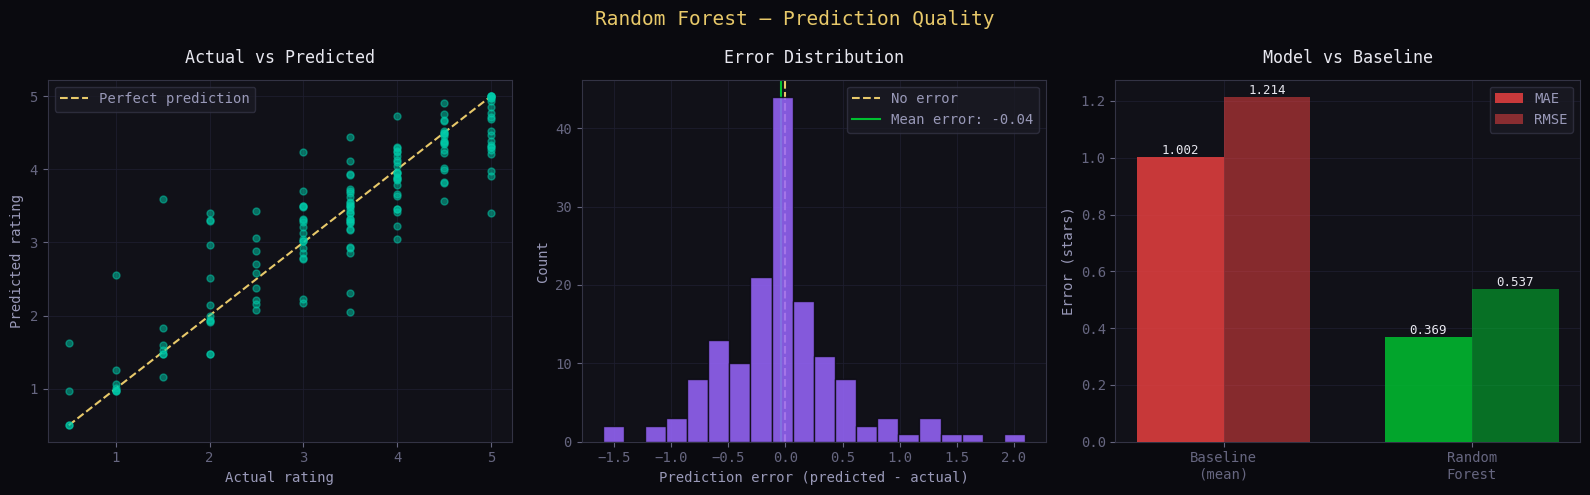

Saved: output/30_prediction_quality.png


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0a0a0f')
fig.suptitle('Random Forest — Prediction Quality', color=GOLD, fontsize=14)

# Left: scatter actual vs predicted
ax = axes[0]
ax.scatter(y_test, rf_pred, alpha=0.5, s=25, color=TEAL, zorder=3)
ax.plot([0.5, 5.0], [0.5, 5.0], color=GOLD, linestyle='--', linewidth=1.5,
        label='Perfect prediction')
ax.set_xlabel('Actual rating')
ax.set_ylabel('Predicted rating')
ax.set_title('Actual vs Predicted')
ax.set_facecolor('#111118')
ax.legend(facecolor='#1a1a24', edgecolor='#333344', labelcolor='#9999b8')

# Middle: error distribution
errors = rf_pred - y_test
ax = axes[1]
ax.hist(errors, bins=20, color=PURPLE, alpha=0.85, zorder=3, edgecolor='#0a0a0f')
ax.axvline(0, color=GOLD, linestyle='--', linewidth=1.5, label='No error')
ax.axvline(errors.mean(), color=GREEN, linestyle='-', linewidth=1.5,
           label=f'Mean error: {errors.mean():+.2f}')
ax.set_xlabel('Prediction error (predicted - actual)')
ax.set_ylabel('Count')
ax.set_title('Error Distribution')
ax.set_facecolor('#111118')
ax.legend(facecolor='#1a1a24', edgecolor='#333344', labelcolor='#9999b8')

# Right: baseline vs RF comparison
ax = axes[2]
metrics_compare = {
    'Baseline\n(mean)': [baseline_mae, baseline_rmse],
    'Random\nForest':   [rf_mae, rf_rmse],
}
x = np.arange(2)
width = 0.35
bars1 = ax.bar(x - width/2, [v[0] for v in metrics_compare.values()],
               width, label='MAE', color=[RED, GREEN], alpha=0.85, zorder=3)
bars2 = ax.bar(x + width/2, [v[1] for v in metrics_compare.values()],
               width, label='RMSE', color=[RED, GREEN], alpha=0.55, zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(list(metrics_compare.keys()))
ax.set_ylabel('Error (stars)')
ax.set_title('Model vs Baseline')
ax.set_facecolor('#111118')
ax.legend(facecolor='#1a1a24', edgecolor='#333344', labelcolor='#9999b8')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=9, color='#e8e8f0')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '30_prediction_quality.png'),
            dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Saved: output/30_prediction_quality.png")


## 9. Feature importance

Which features actually drive my ratings?
Random Forest computes this automatically — it measures how much
each feature reduces prediction error across all trees.


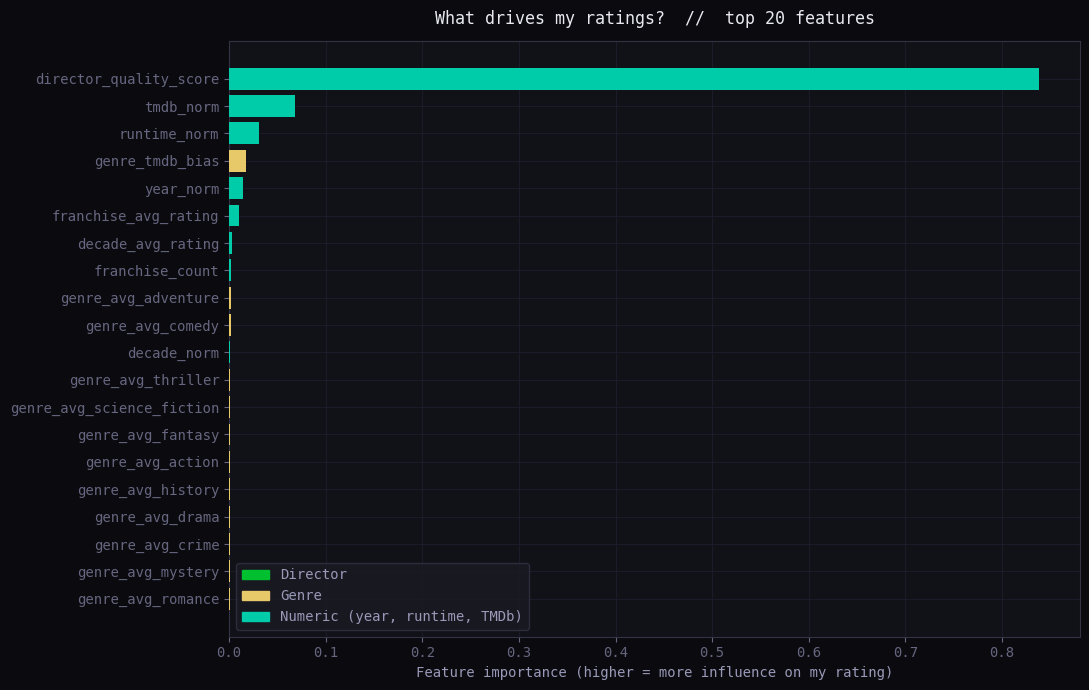

Saved: output/31_feature_importance.png


In [33]:
importances = pd.Series(rf.feature_importances_, index=feature_names_v2)
top_features = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0a0a0f')

colors_fi = [GREEN if 'dir_' in f else GOLD if 'genre_' in f else TEAL
             for f in top_features.index]
ax.barh(top_features.index, top_features.values, color=colors_fi, zorder=3)
ax.set_xlabel('Feature importance (higher = more influence on my rating)')
ax.set_title('What drives my ratings?  //  top 20 features')
ax.set_facecolor('#111118')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=GREEN, label='Director'),
    Patch(color=GOLD,  label='Genre'),
    Patch(color=TEAL,  label='Numeric (year, runtime, TMDb)'),
], facecolor='#1a1a24', edgecolor='#333344', labelcolor='#9999b8')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '31_feature_importance.png'),
            dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Saved: output/31_feature_importance.png")


## 10. Learning curve

How does performance improve as we add more training data?

- If train and test scores are both high → model is learning well
- If train is high but test is low → **overfitting** (memorising, not learning)
- If both are low → **underfitting** (model is too simple)


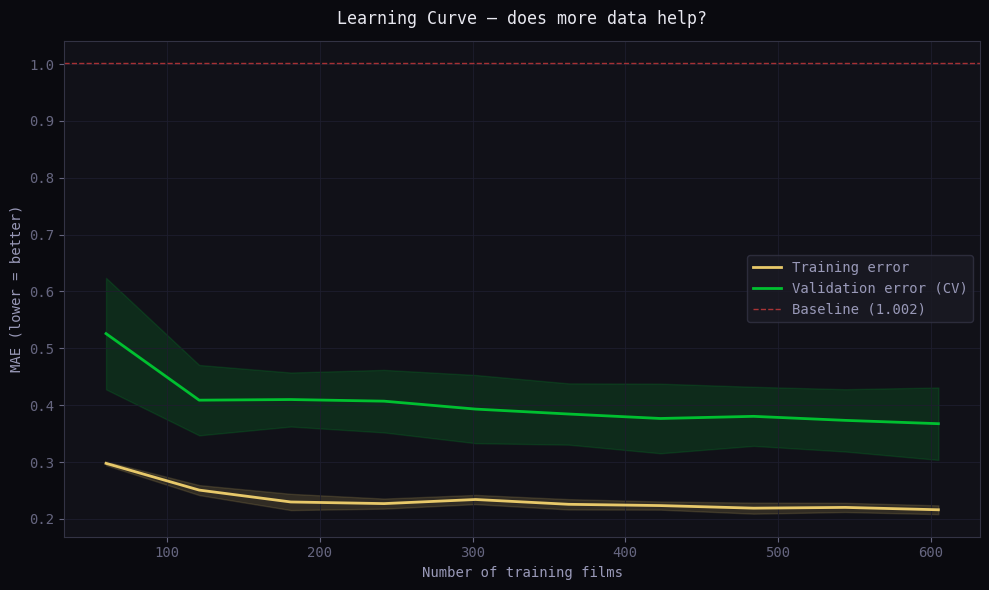

Saved: output/32_learning_curve.png


In [34]:
train_sizes, train_scores, test_scores = learning_curve(
    rf, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
)

train_mean = -train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = -test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0a0a0f')

ax.plot(train_sizes, train_mean, color=GOLD, linewidth=2, label='Training error')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color=GOLD)

ax.plot(train_sizes, test_mean, color=GREEN, linewidth=2, label='Validation error (CV)')
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                alpha=0.15, color=GREEN)

ax.axhline(baseline_mae, color=RED, linestyle='--', linewidth=1,
           alpha=0.7, label=f'Baseline ({baseline_mae:.3f})')

ax.set_xlabel('Number of training films')
ax.set_ylabel('MAE (lower = better)')
ax.set_title('Learning Curve — does more data help?')
ax.set_facecolor('#111118')
ax.legend(facecolor='#1a1a24', edgecolor='#333344', labelcolor='#9999b8')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '32_learning_curve.png'),
            dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Saved: output/32_learning_curve.png")


## 11. Predict ratings for watchlist — improved model

Now using the enriched feature vector with weighted director/genre signals.
Denis Villeneuve, Nolan, franchise history — all properly weighted.


In [35]:
watchlist_enriched = pd.read_csv(os.path.join(DATA_DIR, 'watchlist_enriched.csv'))
candidates = pd.read_csv(os.path.join(DATA_DIR, 'candidates.csv'))

# Fill missing values
for col in ['genres', 'directors', 'countries', 'production_companies']:
    if col in watchlist_enriched.columns:
        watchlist_enriched[col] = watchlist_enriched[col].fillna('')
    else:
        watchlist_enriched[col] = ''

print(f"Watchlist: {len(watchlist_enriched)} films")
has_genres = (watchlist_enriched['genres'] != '').sum()
has_dirs   = (watchlist_enriched['directors'] != '').sum()
print(f"  Has genres:    {has_genres} ({has_genres/len(watchlist_enriched)*100:.0f}%)")
print(f"  Has directors: {has_dirs} ({has_dirs/len(watchlist_enriched)*100:.0f}%)")

def predict_pool_v2(pool_df, pool_name, top_n=20):
    X_pool = np.array([build_features_v2(row) for _, row in pool_df.iterrows()], dtype=float)
    X_pool = np.nan_to_num(X_pool, nan=0.0)
    preds  = rf.predict(X_pool)
    pool_df = pool_df.copy()
    pool_df['predicted_rating'] = preds.round(2)
    top = pool_df.nlargest(top_n, 'predicted_rating')

    print(f"\nTop {top_n} predicted ratings — {pool_name}:")
    for _, row in top.iterrows():
        genres = str(row.get('genres','')).replace('|',' · ')[:30]
        dirs   = str(row.get('directors','')).split('|')[0][:20]
        print(f"  {row['Name'][:40]:<42} {row['predicted_rating']:.2f}  {dirs}  {genres}")
    return pool_df

wl_preds_v2   = predict_pool_v2(watchlist_enriched, "Watchlist (improved)", top_n=20)
disc_preds_v2 = predict_pool_v2(candidates, "Discoveries (improved)", top_n=20)

wl_preds_v2.to_csv(os.path.join(DATA_DIR, 'watchlist_predictions_v2.csv'), index=False)
disc_preds_v2.to_csv(os.path.join(DATA_DIR, 'discovery_predictions_v2.csv'), index=False)
print("\nSaved!")


Watchlist: 251 films
  Has genres:    251 (100%)
  Has directors: 251 (100%)

Top 20 predicted ratings — Watchlist (improved):
  The Two Popes                              5.00  Fernando Meirelles  Drama · History
  Sanjuro                                    5.00  Akira Kurosawa  Drama · Action · Comedy
  High and Low                               5.00  Akira Kurosawa  Drama · Crime · Thriller
  There Will Be Blood                        5.00  Paul Thomas Anderson  Drama
  Central Station                            5.00  Walter Salles  Drama
  Eyes Wide Shut                             5.00  Stanley Kubrick  Drama · Thriller · Mystery
  Dreams                                     5.00  Akira Kurosawa  Fantasy · Drama
  Tokyo Sonata                               5.00  Kiyoshi Kurosawa  Drama
  Magnolia                                   5.00  Paul Thomas Anderson  Drama
  Ran                                        5.00  Akira Kurosawa  Action · Drama · History
  Barry Lyndon              

## 12. Top predicted films — visualised

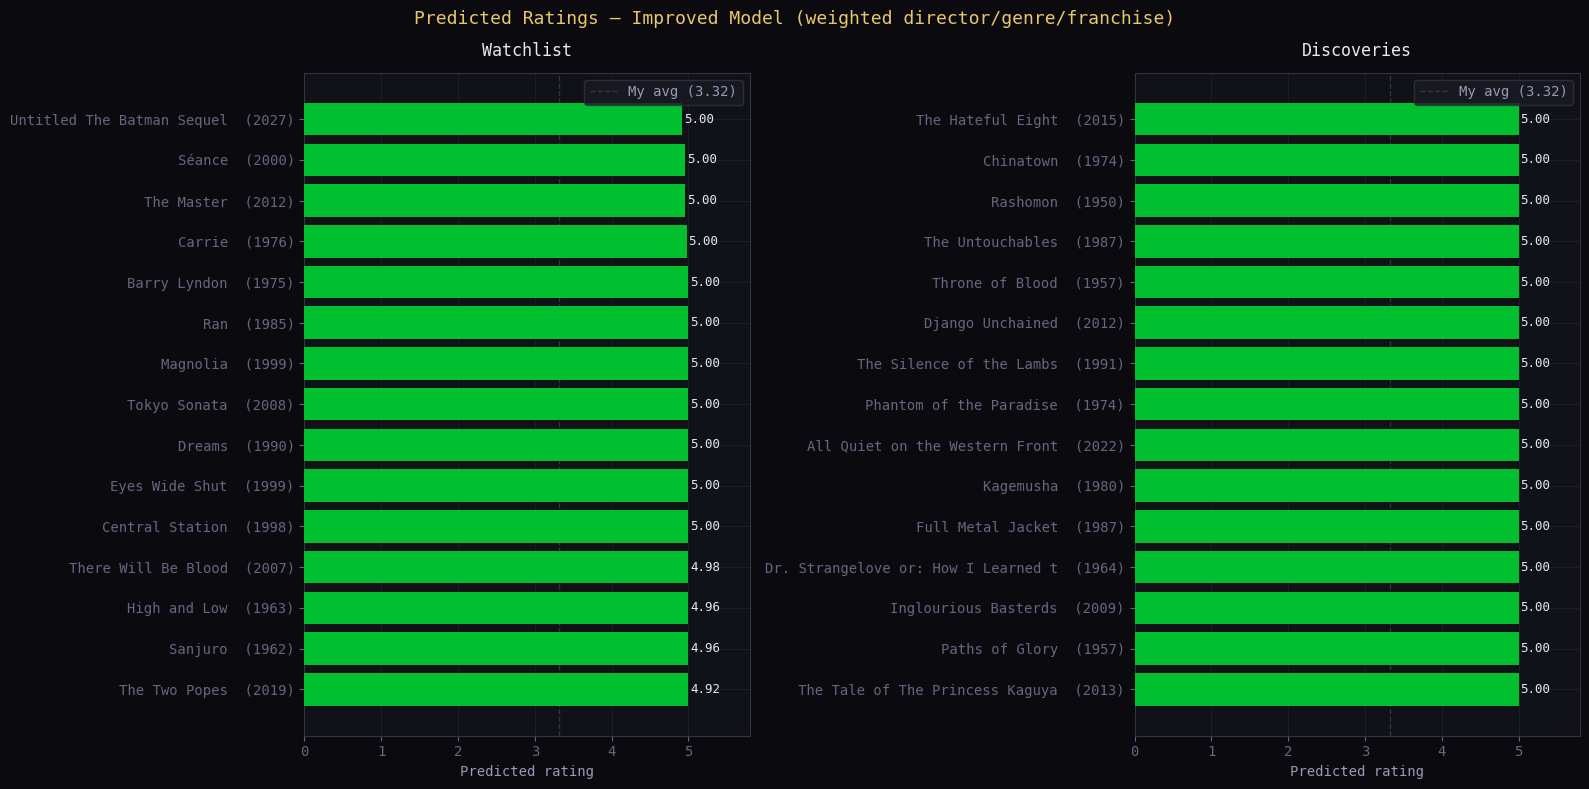

Saved: output/34_predicted_ratings_v2.png


In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('#0a0a0f')
fig.suptitle('Predicted Ratings — Improved Model (weighted director/genre/franchise)',
             color=GOLD, fontsize=13)

for ax, pool_df, title in [
    (ax1, wl_preds_v2,   'Watchlist'),
    (ax2, disc_preds_v2, 'Discoveries'),
]:
    top = pool_df.nlargest(15, 'predicted_rating')
    colors = [GREEN if r >= 4.5 else GOLD if r >= 4.0 else TEAL
              for r in top['predicted_rating']]
    
    bars = ax.barh(
        [f"{row['Name'][:35]}  ({int(row['Year'])})" for _, row in top.iterrows()],
        top['predicted_rating'],
        color=colors[::-1], zorder=3
    )
    for bar, val in zip(bars, top['predicted_rating'].values[::-1]):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=9, color='#e8e8f0')
    
    ax.set_xlabel('Predicted rating')
    ax.set_title(title)
    ax.set_xlim(0, 5.8)
    ax.set_facecolor('#111118')
    ax.axvline(x=df['Rating'].mean(), color='#444455', linestyle='--',
               linewidth=1, alpha=0.7, label=f'My avg ({df["Rating"].mean():.2f})')
    ax.legend(facecolor='#1a1a24', edgecolor='#333344', labelcolor='#9999b8')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '34_predicted_ratings_v2.png'),
            dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Saved: output/34_predicted_ratings_v2.png")


## 13. Summary

**Improvements over v1:**
- Directors weighted by your actual avg rating (not binary 0/1)
- Genres weighted by your actual avg rating
- Countries and decades weighted by your actual avg rating  
- Production companies as features (A24, Marvel, Nolan...)
- Franchise signal — if you loved Dune 1+2, Dune 3 scores higher
- TMDb bias per genre — captures where you diverge from the crowd

**Expected improvement:** predictions for franchise films and favourite directors should now reflect your real taste much better.
